# Model Evaluation — Teeth Segmentation
Evaluates the trained model on the validation set.
Reports mAP@50, mAP@75, MAE on tooth count, and saves visualisations.


In [1]:
from pathlib import Path
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import sys
import os
import pandas as pd
import random 

ROOT_DIR = Path().resolve().parent
sys.path.append(str(ROOT_DIR))

DATA_DIR    = ROOT_DIR / 'data'
IMG_DIR     = DATA_DIR / 'images'
ANN_DIR     = DATA_DIR / 'annotations'
RESULTS_DIR = ROOT_DIR / 'outputs' / 'results' / 'maskrcnn_torch'
csv_path = RESULTS_DIR / 'training_history.csv'


from models.teeth_segmentation import (
    build_model,
    evaluate,
    predict,
    TeethDataset,
)

from utils.preprocessing import load_image, enhance_contrast
from configs.model_config import CONF_THRESHOLD, FDI_CLASSES, NUM_CLASSES

## Load Model

In [2]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = build_model(NUM_CLASSES)

model.load_state_dict(
    torch.load(
        RESULTS_DIR / 'best.pth',
        map_location=DEVICE,
        weights_only=True
    )
)

model.to(DEVICE)
model.eval()

print("Model loaded")


Model loaded


## Run COCO Evaluation

In [3]:
evaluate()

Loaded 399 images with annotations
loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
Evaluating 399 val images...
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=1.45s).
Accumulating evaluation results...
DONE (t=0.30s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.560
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.817
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.673
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.391
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.636
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.592
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.606


## Plot Training/Validation Loss

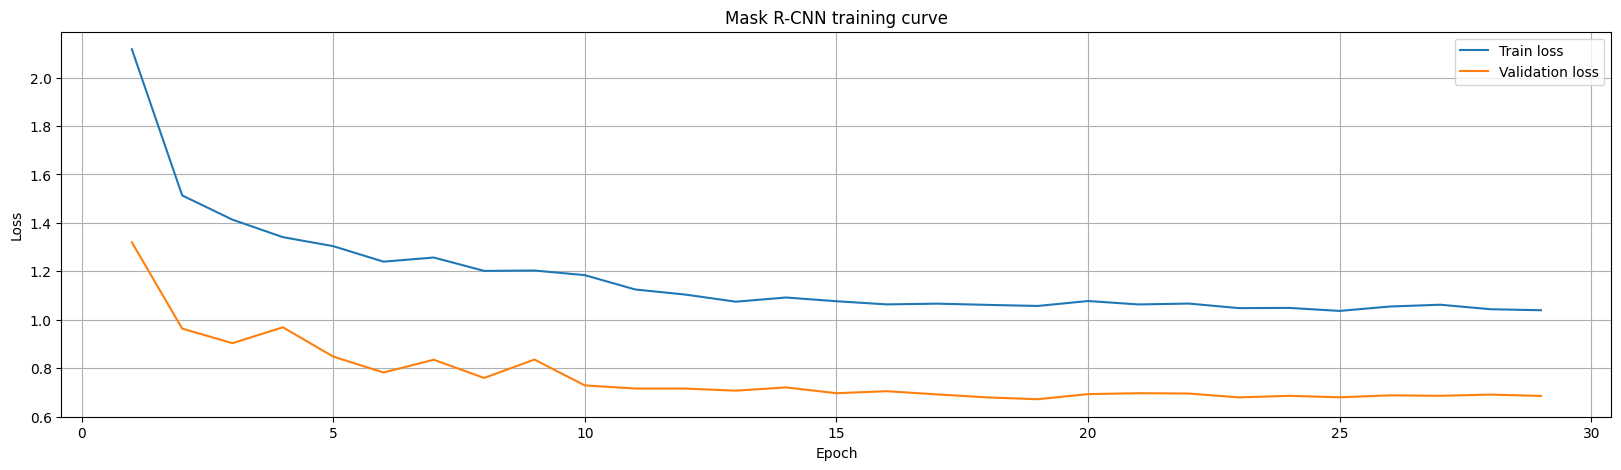

In [4]:
df = pd.read_csv(csv_path)

plt.figure(figsize=(20,5))
plt.plot(df['epoch'],df['train_loss'],label="Train loss")
plt.plot(df['epoch'],df['val_loss'],label= "Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Mask R-CNN training curve")
plt.legend()
plt.grid()
plt.show()

## Best epoch

In [5]:
best_epoch = int(df['val_loss'].idxmin()) + 1
best_val_loss = df['val_loss'].min()
print(f'Best epoch: {best_epoch}  val_loss: {best_val_loss:.4f}')

Best epoch: 19  val_loss: 0.6715


## Load Validation Images

In [6]:
dataset_val = TeethDataset(
    ANN_DIR / "val.json",
    IMG_DIR,
)

print("Validation images:", len(dataset_val))

Loaded 399 images with annotations
Validation images: 399


## Show random VAlidation images

In [7]:
random_samples = random.sample(
    dataset_val.images,
    5
)

for img_info in random_samples:
    print(img_info["file_name"])

for img_info in random_samples:

    image_path = IMG_DIR / img_info["file_name"]

    print(f"\nPredicting: {image_path.name}")

    predict(image_path)

pan-08281.jpg
pan-08636.jpg
pan-04269.jpg
pan-05520.jpg
pan-07081.jpg

Predicting: pan-08281.jpg
Detected: 25 teeth
Saved: /home/dorina/Desktop/Teeth-Segmentation-OdontoAI/outputs/visualizations/pred_pan-08281.jpg

Predicting: pan-08636.jpg
Detected: 36 teeth
Saved: /home/dorina/Desktop/Teeth-Segmentation-OdontoAI/outputs/visualizations/pred_pan-08636.jpg

Predicting: pan-04269.jpg
Detected: 37 teeth
Saved: /home/dorina/Desktop/Teeth-Segmentation-OdontoAI/outputs/visualizations/pred_pan-04269.jpg

Predicting: pan-05520.jpg
Detected: 43 teeth
Saved: /home/dorina/Desktop/Teeth-Segmentation-OdontoAI/outputs/visualizations/pred_pan-05520.jpg

Predicting: pan-07081.jpg
Detected: 36 teeth
Saved: /home/dorina/Desktop/Teeth-Segmentation-OdontoAI/outputs/visualizations/pred_pan-07081.jpg


## DIsplay Predictions

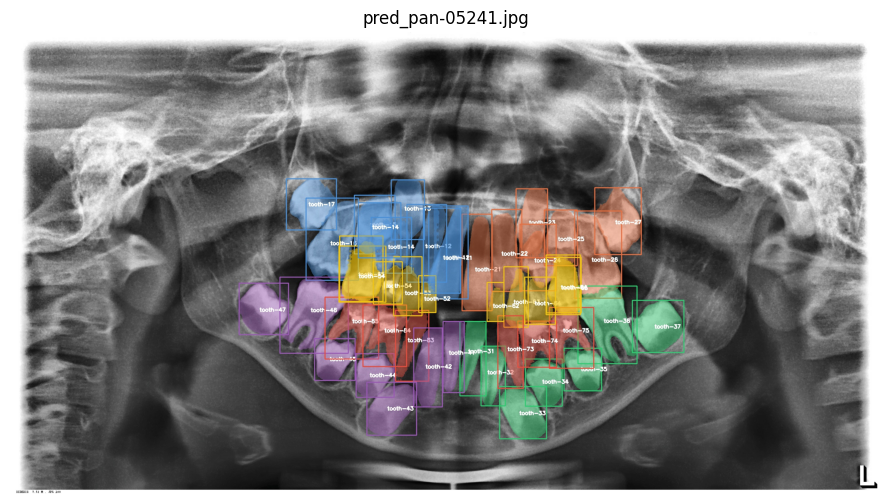

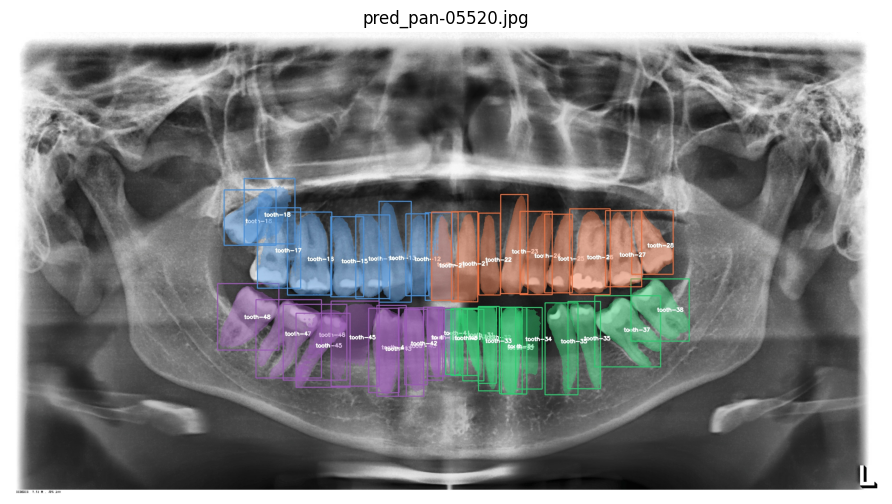

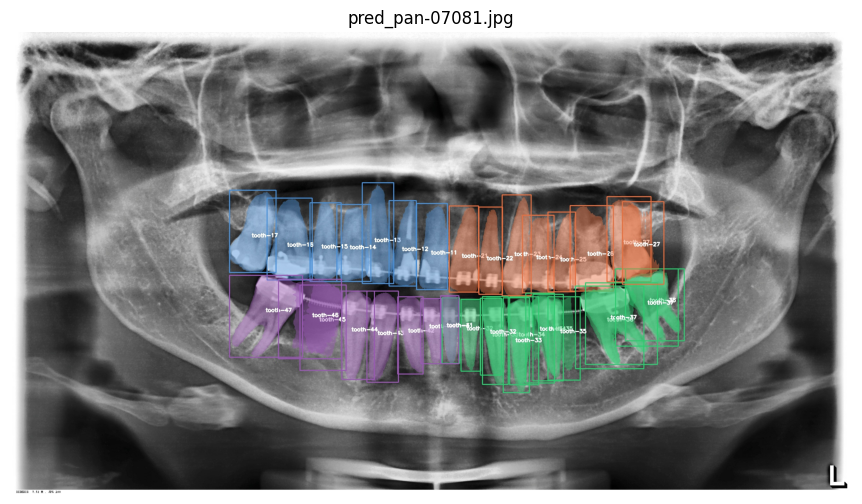

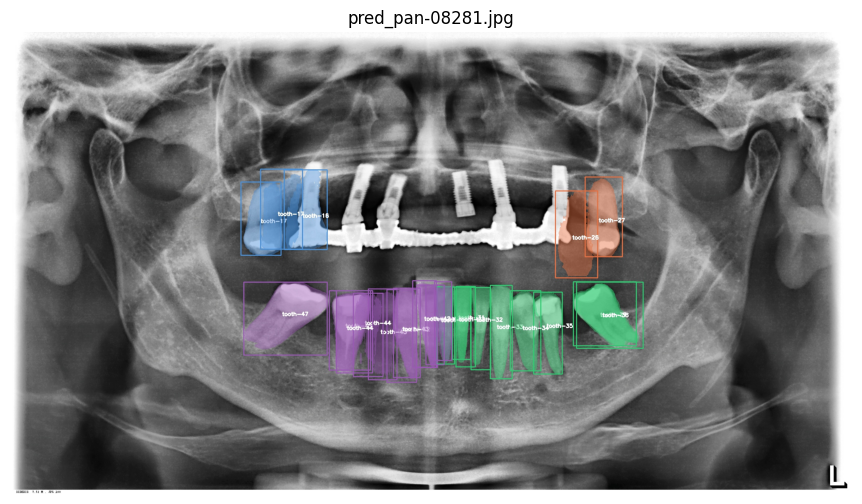

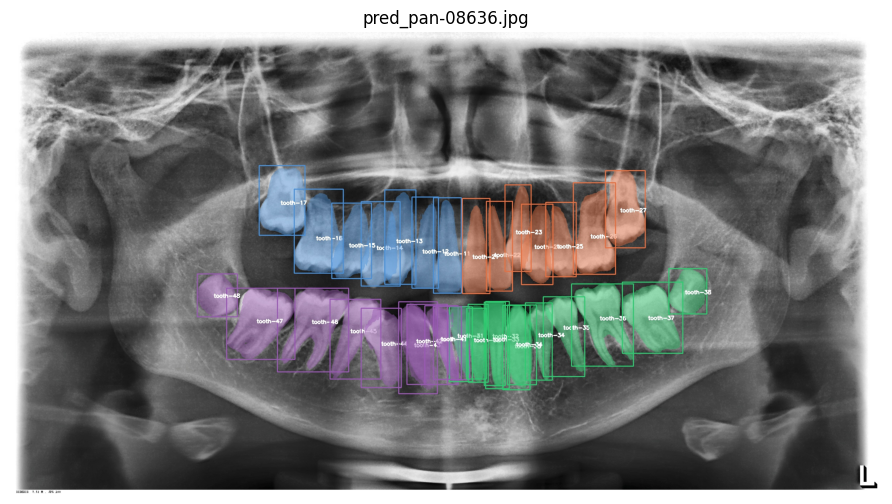

In [8]:
import cv2

viz_dir = ROOT_DIR / "outputs" / "visualizations"

pred_files = sorted(
    viz_dir.glob("pred_*")
)

for file in pred_files[-5:]:

    img = cv2.imread(str(file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,6))
    plt.imshow(img)
    plt.title(file.name)
    plt.axis("off")
    plt.show()

## Evaluate on a specific image

Detected: 41 teeth
Saved: /home/dorina/Desktop/Teeth-Segmentation-OdontoAI/outputs/visualizations/pred_pan-00031.jpg


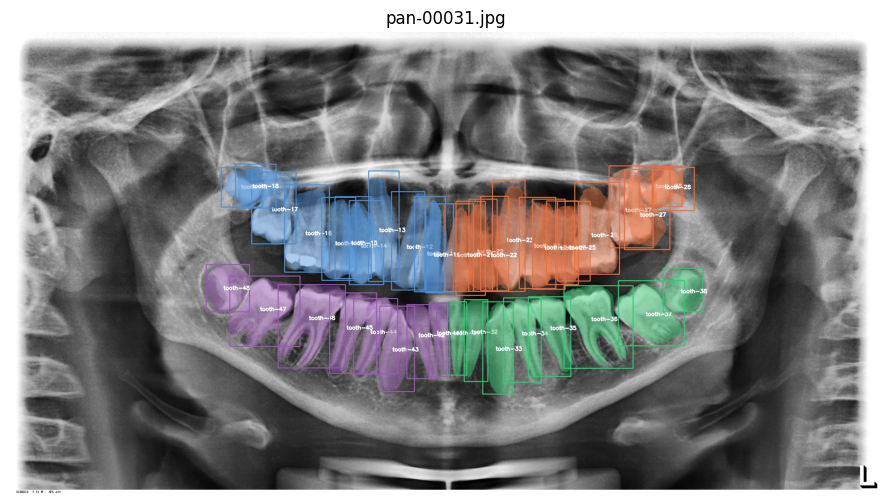

In [9]:
image_path = DATA_DIR / 'test' / 'pan-00031.jpg'  # pick any test image
predict(image_path)

img = cv2.imread(str(ROOT_DIR / 'outputs' / 'visualizations' / f'pred_{image_path.name}'))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.title(image_path.name)
plt.axis('off')
plt.show()

In [10]:
import json, torchvision.transforms.functional as F

anns_by_image = {}
with open(ANN_DIR / 'val.json') as f:
    for ann in json.load(f)['annotations']:
        anns_by_image.setdefault(ann['image_id'], []).append(ann)

n_det, n_gt = [], []
with torch.no_grad():
    for img in dataset_val.images:
        t = F.to_tensor(enhance_contrast(load_image(str(IMG_DIR/img['file_name'])), 'clahe')).unsqueeze(0).to(DEVICE)
        scores = model(t)[0]['scores'].cpu().numpy()
        n_det.append((scores >= CONF_THRESHOLD).sum())
        n_gt.append(len(anns_by_image.get(img['id'], [])))

diffs = np.abs(np.array(n_det) - np.array(n_gt))
print(f'MAE: {diffs.mean():.1f} teeth | detected: {np.mean(n_det):.1f} vs GT: {np.mean(n_gt):.1f}')

MAE: 9.3 teeth | detected: 37.9 vs GT: 28.7
